<a href="https://colab.research.google.com/github/Rifat31002/BasicCalculatorWinForms/blob/master/ViT_learn_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## https://www.youtube.com/watch?v=ZRo74xnN2SI
# Image → Patches → Embedding → Attention → CLS Token → Classifier

In [ ]:
# import libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.utils.data as dataloader   # importing data loader from torch
import torch.nn as nn

In [ ]:
# image tranformation to tensor format
transformation_operation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    #transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Normalization for CIFAR-10 (RGB images)
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)) # to see if anything improves
])

In [ ]:
# Import Datasets/ Download datasets
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform = transformation_operation)
val_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform = transformation_operation)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


In [ ]:
# define variable/
num_classes = 10         # final number of the nodes in ViT (CIFAR-10 also has 10 classes)
batch_size = 64          #
num_channels = 3         # 3 for RGB coloured images (CIFAR-10), 1 for black and white
img_size= 32             # CIFAR-10 dataset resolution is 32X32
patch_size= 2            # Adjusted to divide 32 evenly, giving 8x8 = 64 patches
num_patches = (img_size//patch_size)**2 # floor operation using  // this rounds the number
embedding_dim = 128     # 64 was original
attention_heads =  8    #  4 -> 8 was original, this single head attention is 1 this could be different
transformer_blocks= 6     # originally was 4
mlp_hidden_nodes = 256    # 128 -> 256 multi layer perceptron
learning_rate = 0.001     #
epochs = 20              # try 5> 10 > 20 or even 30

In [ ]:
# Define datasets batches
train_loader = dataloader.DataLoader(train_dataset, batch_size, shuffle= True) # define how many images do i want ?
val_loader = dataloader.DataLoader(val_dataset, batch_size, shuffle= True)      #

In [ ]:
# defining class
# Part 1: patch embedding
class PatchEmbedding(nn.Module):
  def __init__(self):
    super().__init__()
    # producing non overlapping patches using 2D concvolution, this is the value of x
    self.patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)

  def forward(self, x): # self will pass the above line
      x = self.patch_embed(x)    # Patch embedding
      x = x.flatten(2)           # Flattening
      x = x.transpose(1,2)      # Transpose
      return x
      # return self.patch_embed(x).flatten(2).transpose(1,2) # above code in single line


In [ ]:
# TransformerEncoder (MultiheadAttention) part This combines everything.
class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim) # defining 1st layer normalisation
    self.layer_norm2 = nn.LayerNorm(embedding_dim) # defining 2nd layer normalisaiton
    self.multihead_attention = nn.MultiheadAttention(embedding_dim, attention_heads, batch_first=True) # defining multihead attention

    # MLP Block: defininf the Multi layer perceptron inside the transformer encoder block, GELU activation . Adds non-linearity (learning complex patterns)
    self.mlp = nn.Sequential( nn.Linear(embedding_dim, mlp_hidden_nodes), nn.GELU(), nn.Linear(mlp_hidden_nodes, embedding_dim), )  # this mlp is from the classic MLP inside the transformer encoder

  def forward(self, x):   # defining forward function
    residual1= x  # saving 1st layer normalisation / pre layer normalisation
    x = self.layer_norm1(x)
    x = self.multihead_attention(x, x, x) [0]    # x as query , keys and value place holder , zero index output storing back in x
    x = x + residual1       # Residual Connection Prevents information loss

    residual2 = x   # saving the 2nd layer normalisation / aftre the MHA post layer normalisation
    x = self.layer_norm2(x)
    x = self.mlp(x)
    x = x + residual2
    return x # value of x changing in here

In [ ]:
# Part 3: MLP head classification Takes final representation , Converts to 10 classes

class MLP_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_norm1 = nn.LayerNorm(embedding_dim)
    self.mlp_head = nn.Linear(embedding_dim, num_classes) # linear projection from embedding dimention into the number of classes(10)

  def forward( self, x):
      x = self.layer_norm1(x) # only passing the classification token.
      x = self.mlp_head(x)

      return x

In [ ]:
# define the class transformer

class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding = PatchEmbedding()
    self.cls_token = nn.Parameter(torch.randn(1,1, embedding_dim))  # Position embedding
    self.position_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim)) # Position embedding as learning parameter
    self.transformer_blocks = nn.Sequential(*[TransformerEncoder()for _ in range (transformer_blocks)])
    self.mlp_head = MLP_head()      # cls token passed into MLP head

  def forward(self, x):
      x = self.patch_embedding(x)
      B = x.size(0) # to handle dimentionlaity issue create a batch variable
      # batch size is 64, each batch need 64 classification for every image one patch (Batch, No of patch, Patch)
      class_tokens = self.cls_token.expand(B, -1, -1)
      x = torch.cat((class_tokens, x), dim = 1)
      x = x+self.position_embedding       #Add position embedding Adds spatial info: “This patch is top-left, this is bottom-right”
      x = self.transformer_blocks(x) # x goes through the transformer and comes out Learn relationships between patches
      x = x[:,0]     # every batch only picking 0'th item This is the final image representation
      x = self.mlp_head(x)

      return x    # 10, dimensional class
    # Class token
    # position embedding
# token passed into MLP

In [ ]:
# setting up trainning  and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer().to(device) # name of the class which define the ViT
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate) # Updates weights. Use adam as optimiser
criterion = nn.CrossEntropyLoss() # the loss function Measures prediction error

In [ ]:
#  Sample a data point from the train_loader
data_point, label = next(iter(train_loader))

 # Patch embedding
print("Shape of data point:", data_point.shape)
patch_embed= nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)
print(patch_embed(data_point).flatten(2).transpose(1,2).shape)
#patch_embed_output= patch_embed(data_point)
# print(patch_embed_output.shape)

# each image become 4X4 16 batches , dimention is 64 batch of 64 images
     # Flattening
# patch_embed_output_flattened= patch_embed_output.flatten(2)
#print(patch_embed_output_flattened.shape)

# Shape of data point: torch.Size([64, 1, 28, 28])
# torch.Size([64, 64, ,4 4])
# torch.Size([64, 64, 16])   # 64 images in each batch

Shape of data point: torch.Size([64, 3, 32, 32])
torch.Size([64, 256, 128])


In [ ]:
for epoch in range (epochs):
  model.train()
  total_loss = 0
  correct_epoch = 0
  total_epoch = 0

  print(f"\nEpoch {epoch+1}") # Changed from epochs+1 to epoch+1

  for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)

    loss = criterion(outputs, labels)  # compare prediction vs truth
    loss.backward() # Backpropagation Compute gradients
    optimizer.step() # Update weights

    total_loss += loss.item()

    preds = outputs.argmax(dim=1)
    correct = (preds==labels).sum().item()
    accuracy = 100.0*correct/labels.size(0)

    correct_epoch += correct
    total_epoch += labels.size(0)

    if batch_idx % 100 ==0:
      print(f" Batch {batch_idx+1:3d}: Loss = {loss.item(): .4f}, Acccuracy = {accuracy: .2f}%")

  # Move these lines inside the epoch loop to print summary per epoch
  if total_epoch > 0: # Add a check to prevent ZeroDivisionError
      epoch_acc = 100.0 * correct_epoch / total_epoch
  else:
      epoch_acc = 0.0 # Assign 0.0 if no samples processed in the epoch
  print(f"== Epoch {epoch+1} Summary: Total Loss = {total_loss:.4f}, Accuracy = {epoch_acc: .2f}%") # why epoch + 1?

  print(len(train_loader))


Epoch 1
 Batch   1: Loss =  2.4476, Acccuracy =  9.38%
 Batch 101: Loss =  1.8493, Acccuracy =  31.25%
 Batch 201: Loss =  1.8601, Acccuracy =  25.00%
 Batch 301: Loss =  1.6400, Acccuracy =  37.50%
 Batch 401: Loss =  1.7302, Acccuracy =  31.25%
 Batch 501: Loss =  1.6511, Acccuracy =  39.06%
 Batch 601: Loss =  1.5344, Acccuracy =  40.62%
 Batch 701: Loss =  1.6044, Acccuracy =  42.19%
== Epoch 1 Summary: Total Loss = 1373.7677, Accuracy =  34.81%
782

Epoch 2
 Batch   1: Loss =  1.4004, Acccuracy =  42.19%
 Batch 101: Loss =  1.4346, Acccuracy =  45.31%
 Batch 201: Loss =  1.6258, Acccuracy =  45.31%
 Batch 301: Loss =  1.4541, Acccuracy =  48.44%
 Batch 401: Loss =  1.5043, Acccuracy =  45.31%
 Batch 501: Loss =  1.3581, Acccuracy =  43.75%
 Batch 601: Loss =  1.3197, Acccuracy =  56.25%
 Batch 701: Loss =  1.3664, Acccuracy =  51.56%
== Epoch 2 Summary: Total Loss = 1134.6462, Accuracy =  47.00%
782

Epoch 3
 Batch   1: Loss =  1.4401, Acccuracy =  62.50%
 Batch 101: Loss =  1.12

In [ ]:
data_point, label = next(iter(train_loader))

print("Shape of the point", data_point.shape)
patch_embed = nn.Conv2d(num_channels, embedding_dim, kernel_size = patch_size, stride = patch_size)
print(patch_embed(data_point).flatten(2).transpose(1,2).shape)

Shape of the point torch.Size([64, 3, 32, 32])
torch.Size([64, 256, 128])


In [ ]:
model.eval()
correct= 0
total = 0

with torch .no_grad():
  for images, labels in val_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)
    correct += labels.size(0)
    total += labels.size(0)

test_acc = 100.0* correct / total
print(f"\n==>Val Accuracy: {test_acc:2f}%")


==>Val Accuracy: 100.000000%


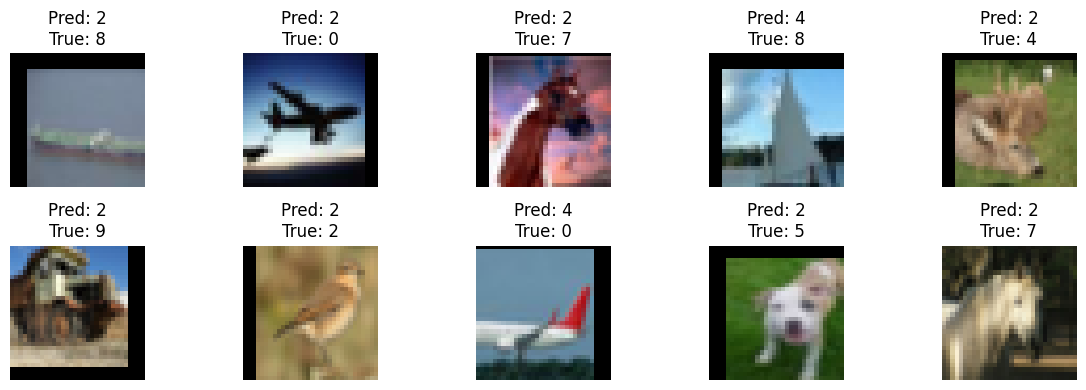

In [ ]:
import matplotlib.pyplot as plt
import torch # Ensure torch is imported
import torch.nn as nn

# Ensure model and device are defined for plotting if kernel state was lost
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# This assumes VisionTransformer and its dependencies are defined in preceding cells.
model = VisionTransformer().to(device)

# show 10 predictions from the first test batch
model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
  outputs = model(images)
  preds = outputs.argmax(dim=1).cpu() # Get predictions here
  labels = labels.cpu()
  images = images.cpu() # Move images to CPU

  # Define mean and std for CIFAR-10 from the transformation_operation
  mean_cifar = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
  std_cifar = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

  # plot first 10 images
plt.figure(figsize=(12,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  # De-normalize and permute dimensions
  img_to_show = images[i] * std_cifar + mean_cifar
  img_to_show = img_to_show.permute(1, 2, 0) # From (C, H, W) to (H, W, C)
  plt.imshow(img_to_show)
  plt.title(f"Pred: { preds[i].item()}\nTrue: {labels[i].item()}")
  plt.axis('off')
plt.tight_layout()
plt.show()